# Group project 3
# Submitted by: Rishi Ram, Vikas Gautam
# Date: 19/1/2025


In [1]:
!pip install kaggle
!pip install tensorflow
!pip install scikeras
!pip install tensorflow-addons

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 8.2 MB/s eta 0:00:00
  Attempting uninstall: typeguard
    Found existing installation: typeguard 4.4.1
    Uninstalling typeguard-4.4.1:
      Successfully uninstalled typeguard-4.4.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
inflect 7.5.0 requires typeguard>=4.0.1, but you have typeguard 2.13.3 which is incompatible.


In [2]:
!pip install opendatasets
!pip install xgboost

In [3]:
import opendatasets as od
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, GridSearchCV
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.decomposition import PCA
import numpy as np
import seaborn as sns
from mlxtend.preprocessing import standardize
from mlxtend.feature_extraction import LinearDiscriminantAnalysis as lda2
import time
import psutil
from scipy.stats import uniform, randint


In [4]:
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
import xgboost as xgb
from sklearn.naive_bayes import GaussianNB
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.optimizers import Adam
from scipy.stats import loguniform
import warnings
warnings.filterwarnings("ignore")

In [5]:
#od.download("https://www.kaggle.com/datasets/rashmi08singh/tesla-stock-market-dataset")

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import os
print(os.listdir('/content/drive/My Drive/WQU/GRp7797/proj3'))

['adult_data2.csv', 'adult_test2.csv', 'Grp 7797_proj3_M7.ipynb']


In [8]:
#import zipfile
#import os

#with zipfile.ZipFile("./archive.zip", 'r') as zip_ref:
#    zip_ref.extractall("stars")

In [9]:
dataset=pd.read_csv("/content/drive/My Drive/WQU/GRp7797/proj2/Stars.csv")
dataset.head()

,Temperature,L,R,A_M,Color,Spectral_Class,Type
0,3068,0.002400,0.1700,16.12,Red,M,0
1,3042,0.000500,0.1542,16.60,Red,M,0
2,2600,0.000300,0.1020,18.70,Red,M,0
3,2800,0.000200,0.1600,16.65,Red,M,0
4,1939,0.000138,0.1030,20.06,Red,M,0


In [10]:
# Step 1: Load the dataset
file_path = "/content/drive/My Drive/WQU/GRp7797/proj3/adult_data2.csv"  # Replace with the path where you downloaded the dataset
adult_df3 = pd.read_csv(file_path,header=None)

In [11]:
# Step 1: Load the dataset
file_path = "/content/drive/My Drive/WQU/GRp7797/proj3/adult_test2.csv"  # Replace with the path where you downloaded the dataset
adult_test3 = pd.read_csv(file_path, skiprows=1, header=None)

In [12]:
adult_test3.shape

(16281, 15)

In [13]:
dataset.shape

(240, 7)

In [14]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     240 non-null    int64  
 1   L               240 non-null    float64
 2   R               240 non-null    float64
 3   A_M             240 non-null    float64
 4   Color           240 non-null    object 
 5   Spectral_Class  240 non-null    object 
 6   Type            240 non-null    int64  
dtypes: float64(3), int64(2), object(2)
memory usage: 13.3+ KB


In [15]:
dataset.describe()

,Temperature,L,R,A_M,Type
count,240.000000,240.000000,240.000000,240.000000,240.000000
mean,10497.462500,107188.361635,237.157781,4.382396,2.500000
std,9552.425037,179432.244940,517.155763,10.532512,1.711394
min,1939.000000,0.000080,0.008400,-11.920000,0.000000
25%,3344.250000,0.000865,0.102750,-6.232500,1.000000
50%,5776.000000,0.070500,0.762500,8.313000,2.500000
75%,15055.500000,198050.000000,42.750000,13.697500,4.000000
max,40000.000000,849420.000000,1948.500000,20.060000,5.000000


In [16]:
data1=dataset.copy()
# Convert 'Color' and 'Spectral Class' columns to categorical
data1['Color'] = data1['Color'].astype('category')
data1['Spectral_Class'] = data1['Spectral_Class'].astype('category')
data1['Type'] = data1['Type'].astype('category')

plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

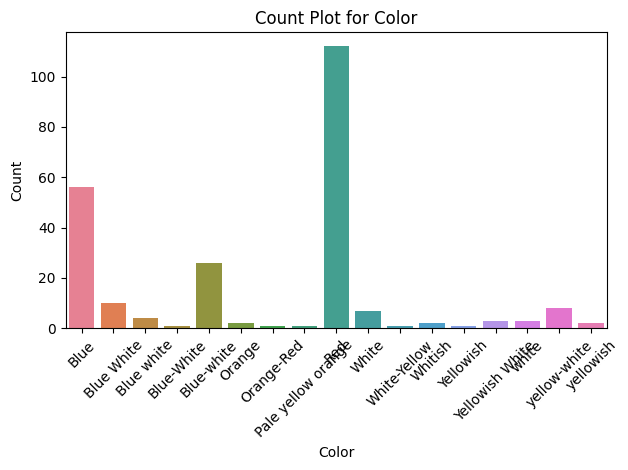

In [17]:
sns.countplot(data=data1, x='Color',hue='Color', legend=False,)#palette="viridis")
plt.title(f"Count Plot for Color")
plt.xlabel("Color")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show();

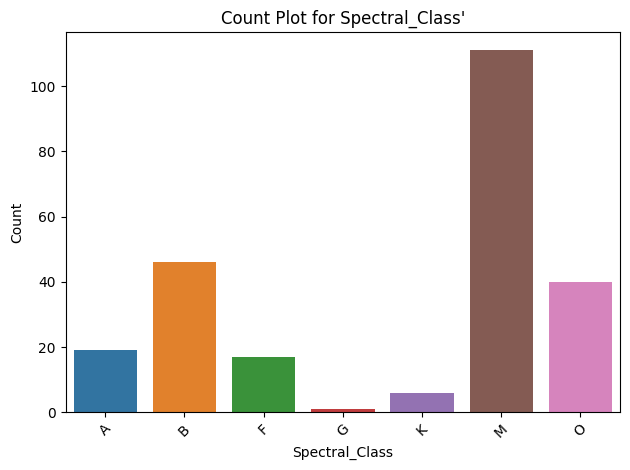

In [18]:
sns.countplot(data=data1, x='Spectral_Class',hue='Spectral_Class', legend=False,)#, palette="viridis")
plt.title(f"Count Plot for Spectral_Class'")
plt.xlabel('Spectral_Class')
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Target Label for Stars dataset

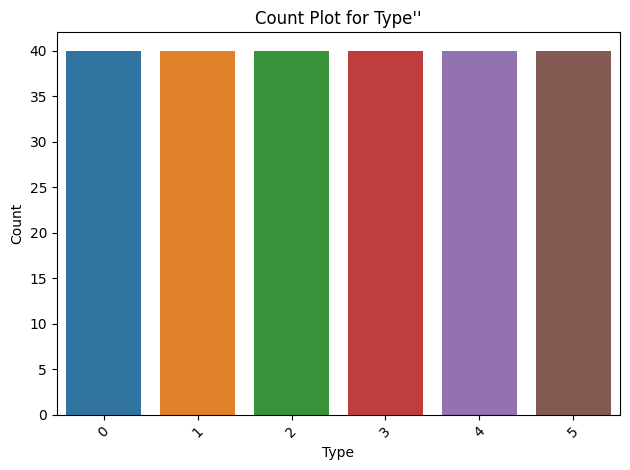

In [19]:
sns.countplot(data=data1, x='Type', hue='Type', legend=False,)#palette="viridis")
plt.title(f"Count Plot for Type''")
plt.xlabel('Type')
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Splitting dataset in train and test data

In [20]:
X1, y1 = dataset.iloc[:, :-1], dataset.iloc[:, -1]
y1.head()

,Type
0,0
1,0
2,0
3,0
4,0


In [21]:
cat_features_list = X1.select_dtypes(include=['object']).columns
cat_features_list

Index(['Color', 'Spectral_Class'], dtype='object')

In [22]:

X1[cat_features_list] = X1[cat_features_list].apply(LabelEncoder().fit_transform)
X1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     240 non-null    int64  
 1   L               240 non-null    float64
 2   R               240 non-null    float64
 3   A_M             240 non-null    float64
 4   Color           240 non-null    int64  
 5   Spectral_Class  240 non-null    int64  
dtypes: float64(3), int64(3)
memory usage: 11.4 KB


In [23]:
X1, y1 = X1.values, LabelEncoder().fit_transform(y1)
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, random_state=10)

## Hyperparameter Tuning for Classification models

## Case1: LDA

In [24]:
# Linear Discriminant Analysis
lda = LinearDiscriminantAnalysis()
lda.fit(X1_train, y1_train)

# Predictions
y_pred1 = lda.predict(X1_test)



In [25]:
# Evaluation
print("Confusion Matrix:")
print(confusion_matrix(y1_test, y_pred1))
print("\nClassification Report:")
print(classification_report(y1_test, y_pred1))
print("\nAccuracy Score:")
print(accuracy_score(y1_test, y_pred1))

Confusion Matrix:
[[12  0  0  0  0  0]
 [ 0 11  0  0  0  0]
 [ 0  0 10  0  0  0]
 [ 0  0  0  7  2  0]
 [ 0  0  0  1  7  0]
 [ 0  0  0  0  0 10]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        10
           3       0.88      0.78      0.82         9
           4       0.78      0.88      0.82         8
           5       1.00      1.00      1.00        10

    accuracy                           0.95        60
   macro avg       0.94      0.94      0.94        60
weighted avg       0.95      0.95      0.95        60


Accuracy Score:
0.95


## Cross Validation for LDA

In [26]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
scores = cross_val_score(LDA(), X1, y1, cv=4)
print("Accuracy: %0.4f (+/- %0.4f)" % (scores.mean(), scores.std() * 2))

Accuracy: 0.9833 (+/- 0.0236)


In [27]:
X11 = standardize(X1)

lda1 = lda2(n_discriminants=None)
lda1.fit(X11, y1)
X_lda1 = lda1.transform(X11)

In [28]:
tot = sum(lda1.e_vals_)
var_exp = [(i / tot)*100 for i in sorted(lda1.e_vals_, reverse=True)]
cum_var_exp = np.cumsum(var_exp)
print (var_exp)

[81.0393685072078, 10.025948195082645, 7.766833604438912, 1.1378905186506167, 0.02995917462002607, -4.848776395586351e-16]


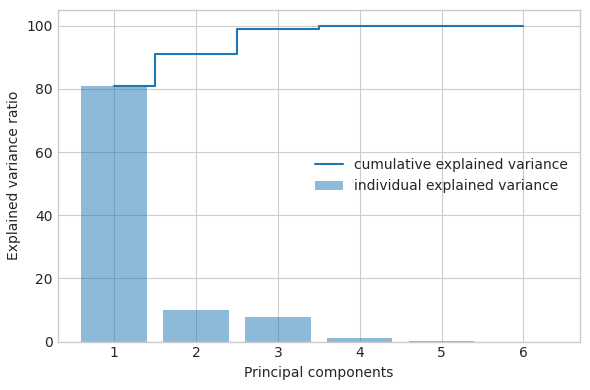

In [29]:
with plt.style.context('seaborn-v0_8-whitegrid'):
    fig, ax = plt.subplots(figsize=(6, 4))
    plt.bar(range(6), var_exp, alpha=0.5, align='center',
            label='individual explained variance')
    plt.step(range(6), cum_var_exp, where='mid',
             label='cumulative explained variance')
    plt.ylabel('Explained variance ratio')
    plt.xlabel('Principal components')
    plt.xticks(range(6))
    ax.set_xticklabels(np.arange(1, X11.shape[1] + 1))
    plt.legend(loc='best')
    plt.tight_layout()

## Hyperparameter Tuning: looks like two componnents are sufficient

## Case2: SVM

In [30]:
# Standardize the numerical features
scaler = StandardScaler()
X2_train = scaler.fit_transform(X1_train)
X2_test = scaler.transform(X1_test)

In [31]:
X2 = scaler.fit_transform(X1)
print (X2.shape)
print (y1.shape)

(240, 6)
(240,)


In [32]:
# Create and train the SVM model
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X2_train, y1_train)

# Make predictions
y_pred2 = svm_model.predict(X2_test)

In [33]:
# Evaluation
print("Confusion Matrix:")
cm2 = confusion_matrix(y1_test, y_pred2)
print(cm2)

print("\nClassification Report:")
print(classification_report(y1_test, y_pred2))

print("\nAccuracy Score:")
print(accuracy_score(y1_test, y_pred2))

Confusion Matrix:
[[12  0  0  0  0  0]
 [ 0 11  0  0  0  0]
 [ 0  0 10  0  0  0]
 [ 0  0  0  9  0  0]
 [ 0  0  0  1  7  0]
 [ 0  0  0  0  0 10]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        10
           3       0.90      1.00      0.95         9
           4       1.00      0.88      0.93         8
           5       1.00      1.00      1.00        10

    accuracy                           0.98        60
   macro avg       0.98      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60


Accuracy Score:
0.9833333333333333


## Cross Validation for SVM

In [34]:
svm_model2 = SVC(kernel='rbf', random_state=42)
scores2 = cross_val_score(svm_model2, X2, y1, cv=5)
print("Accuracy: %0.4f (+/- %0.4f)" % (scores2.mean(), scores2.std() * 2))
scores2

Accuracy: 0.9583 (+/- 0.0589)


array([1.        , 0.9375    , 0.95833333, 0.97916667, 0.91666667])

## Hyper Parameter tuning for SVM

In [35]:
from sklearn.model_selection import GridSearchCV


from sklearn.svm import SVC
param_grid = {
    'C': [0.1, 1,3, 5,10],
    'gamma': [0.001, 0.01, 0.1],
    'kernel': ['linear','poly', 'rbf']
}
grid_search = GridSearchCV(SVC(), param_grid, cv=5)
grid_search.fit(X2, y1)
print(grid_search.best_params_)

{'C': 3, 'gamma': 0.001, 'kernel': 'linear'}


## {'C': 3, 'gamma': 0.001, 'kernel': 'linear'}

## Case3: Neural Networks
## GridSearchCV as hyperparater tuning

In [36]:
# Define the neural network model
mlp = MLPClassifier(max_iter=1000, random_state=42)

# Define hyperparameters for grid search
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
    'activation': ['relu', 'tanh','softmax'],
    'solver': ['adam', 'sgd','rmsprop'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive'],
}

print ()
# Step : Perform RandomSearchCV
print("Starting GridSearchCV on Neural Networks...")
start_time = time.time()
initial_memory = psutil.Process().memory_info().rss / (1024 ** 2)  # Memory in MB
# Set up GridSearchCV
grid_search = GridSearchCV(estimator=mlp, param_grid=param_grid, cv=3, n_jobs=-1, scoring='accuracy')

# Fit the model to the training data
grid_search.fit(X2_train, y1_train)

elapsed_time = time.time() - start_time
final_memory = psutil.Process().memory_info().rss / (1024 ** 2)  # Memory in MB
memory_used = final_memory - initial_memory
print(f"Memory used during GridSearchCV: {memory_used:.2f} MB")
print(f"GridSearchCV completed in {elapsed_time:.2f} seconds.")
print ()

# Best parameters and corresponding accuracy
best_params = grid_search.best_params_
best_score = grid_search.best_score_

best_params, best_score


Starting GridSearchCV on Neural Networks...
Memory used during GridSearchCV: 2.00 MB
GridSearchCV completed in 217.27 seconds.



({'activation': 'relu',
  'alpha': 0.0001,
  'hidden_layer_sizes': (50,),
  'learning_rate': 'constant',
  'solver': 'adam'},
 0.9888888888888889)

## Memory used during GridSearchCV: 2.00 MB
GridSearchCV completed in 217.27 seconds.

({'activation': 'relu',
  'alpha': 0.0001,
  'hidden_layer_sizes': (50,),
  'learning_rate': 'constant',
  'solver': 'adam'},
 0.9888888888888889)

## RandomizedSearchCV as hyperparater tuning

In [37]:
# Step 2: Neural Network with RandomizedSearchCV
# Define the neural network model
mlp = MLPClassifier(max_iter=1000, random_state=42)

# Define hyperparameter space for RandomizedSearchCV
param_distributions_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
    'activation': ['relu', 'tanh','softmax'],
    'solver': ['adam', 'sgd','rmsprop'],
    'alpha': loguniform(0.0001, 0.001,0.01),  # Regularization parameter
    'learning_rate': ['constant', 'adaptive']
}

print ()
# Step : Perform RandomSearchCV
print("Starting RandomizedSearchCV on Neural Networks...")
start_time = time.time()
initial_memory = psutil.Process().memory_info().rss / (1024 ** 2)  # Memory in MB

# RandomizedSearchCV for Neural Network
random_search_mlp = RandomizedSearchCV(
    estimator=mlp,
    param_distributions=param_distributions_mlp,
    n_iter=20,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

# Fit RandomizedSearchCV
random_search_mlp.fit(X2_train, y1_train)

elapsed_time = time.time() - start_time
final_memory = psutil.Process().memory_info().rss / (1024 ** 2)  # Memory in MB
memory_used = final_memory - initial_memory
print(f"Memory used during RandomizedSearchCV: {memory_used:.2f} MB")
print(f"RandomizedSearchCV completed in {elapsed_time:.2f} seconds.")
print ()

# Best parameters and accuracy for Neural Network
best_params_mlp = random_search_mlp.best_params_
best_score_mlp = random_search_mlp.best_score_
test_score_mlp = random_search_mlp.best_estimator_.score(X2_test, y1_test)

print("\nNeural Network - Best Parameters:", best_params_mlp)
print("Neural Network - Best Cross-Validation Accuracy:", best_score_mlp)
print("Neural Network - Test Accuracy:", test_score_mlp)


Starting RandomizedSearchCV on Neural Networks...
Memory used during RandomizedSearchCV: 0.21 MB
RandomizedSearchCV completed in 23.67 seconds.


Neural Network - Best Parameters: {'activation': 'tanh', 'alpha': 0.010100179478331547, 'hidden_layer_sizes': (100, 50), 'learning_rate': 'constant', 'solver': 'adam'}
Neural Network - Best Cross-Validation Accuracy: 0.9888888888888889
Neural Network - Test Accuracy: 0.9833333333333333


## Neural Network - Best Parameters: {'activation': 'tanh', 'alpha': 0.010100179478331547, 'hidden_layer_sizes': (100, 50), 'learning_rate': 'constant', 'solver': 'adam'}
Neural Network - Best Cross-Validation Accuracy: 0.9888888888888889
Neural Network - Test Accuracy: 0.9833333333333333

## Case4: NaiveBayes

In [38]:
# Step 1: Naive Bayes Optimization
# Define the Naive Bayes model
nb_model = GaussianNB()

# Define hyperparameter space for RandomizedSearchCV
param_distributions_nb = {
    'var_smoothing': loguniform(1e-9, 1e-3)  # Explore a logarithmic range for var_smoothing
}

# RandomizedSearchCV for Naive Bayes
random_search_nb = RandomizedSearchCV(
    estimator=nb_model,
    param_distributions=param_distributions_nb,
    n_iter=50,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

# Fit RandomizedSearchCV
random_search_nb.fit(X2_train, y1_train)

# Best parameters and accuracy for Naive Bayes
best_params_nb = random_search_nb.best_params_
best_score_nb = random_search_nb.best_score_
test_score_nb = random_search_nb.best_estimator_.score(X2_test, y1_test)

print("Naive Bayes - Best Parameters:", best_params_nb)
print("Naive Bayes - Best Cross-Validation Accuracy:", best_score_nb)
print("Naive Bayes - Test Accuracy:", test_score_nb)

Naive Bayes - Best Parameters: {'var_smoothing': 0.0005061576888752308}
Naive Bayes - Best Cross-Validation Accuracy: 0.9777777777777779
Naive Bayes - Test Accuracy: 0.95


## Naive Bayes - Best Parameters: {'var_smoothing': 0.0005061576888752308}
Naive Bayes - Best Cross-Validation Accuracy: 0.9777777777777779
Naive Bayes - Test Accuracy: 0.95

## Case5: Random Forest : GridSearchCV and RandomizedSearchCV

In [71]:
# Step 3: Initialize the Random Forest model
rf = RandomForestClassifier(random_state=42)

# Step 4: Define the parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [10,20,30,50, 80],  # Number of trees in the forest
    'max_depth': [2,5, 10, 20, 30],  # Maximum depth of each tree
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split a node
    'min_samples_leaf': [1, 2, 4],  # Minimum number of samples required to be at a leaf node
    'max_features': ['sqrt', 'log2']  # Number of features considered for splitting
}

print ()
# Step : Perform GridSearchCV
print("Starting GridSearchCV on RandomForest...")
start_time = time.time()
initial_memory = psutil.Process().memory_info().rss / (1024 ** 2)  # Memory in MB
# Step 5: Perform GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, scoring='accuracy', verbose=2)
grid_search.fit(X1_train, y1_train)

elapsed_time = time.time() - start_time
final_memory = psutil.Process().memory_info().rss / (1024 ** 2)  # Memory in MB
memory_used = final_memory - initial_memory
print(f"Memory used during GridSearchCV: {memory_used:.2f} MB")
print(f"GridSearchCV completed in {elapsed_time:.2f} seconds.")
print ()
# Step 6: Evaluate the best model
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X1_test)

print("Best Parameters:", grid_search.best_params_)
print("\nClassification Report:\n", classification_report(y1_test, y_pred))
print(f"Accuracy on Test Set: {accuracy_score(y1_test, y_pred):.4f}")


Starting GridSearchCV on RandomForest...
Fitting 5 folds for each of 450 candidates, totalling 2250 fits
Memory used during GridSearchCV: 0.86 MB
GridSearchCV completed in 145.61 seconds.

Best Parameters: {'max_depth': 2, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 20}

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        10
           3       1.00      1.00      1.00         9
           4       1.00      1.00      1.00         8
           5       1.00      1.00      1.00        10

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60

Accuracy on Test Set: 1.0000


## Memory used during GridSearchCV: 0.86 MB
GridSearchCV completed in 145.61 seconds.

Best Parameters: {'max_depth': 2, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 20}



In [40]:
# Step 3: Initialize the Random Forest model
rf = RandomForestClassifier(random_state=42)

# Step 4: Define the parameter grid for hyperparameter tuning
param_grid2 = {
    'n_estimators': [10,20,30,50, 80],  # Number of trees in the forest
    'max_depth': [2,5, 10, 20, 30],  # Maximum depth of each tree
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split a node
    'min_samples_leaf': [1, 2, 4],  # Minimum number of samples required to be at a leaf node
    'max_features': ['sqrt', 'log2']  # Number of features considered for splitting
}
print ()
# Step : Perform RandomSearchCV
print("Starting RandomSearchCV on RandomForest...")
start_time = time.time()
initial_memory = psutil.Process().memory_info().rss / (1024 ** 2)  # Memory in MB
# Step 5: Perform GridSearchCV

rand_search = RandomizedSearchCV(estimator=rf, param_distributions=param_grid2, n_iter=50,
                                   cv=5, n_jobs=-1, random_state=42, scoring='accuracy', verbose=2)
rand_search.fit(X1_train, y1_train)

elapsed_time = time.time() - start_time

final_memory = psutil.Process().memory_info().rss / (1024 ** 2)  # Memory in MB
memory_used = final_memory - initial_memory
print(f"Memory used during RandomizedSearchCV: {memory_used:.2f} MB")
print(f"RandomizedSearchCV completed in {elapsed_time:.2f} seconds.")
print ()
# Step 6: Evaluate the best model
best_rf2 = rand_search.best_estimator_
y_pred = best_rf2.predict(X1_test)

print("Best Parameters:", rand_search.best_params_)
print("\nClassification Report:\n", classification_report(y1_test, y_pred))
print(f"Accuracy on Test Set: {accuracy_score(y1_test, y_pred):.4f}")


Starting RandomSearchCV on RandomForest...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Memory used during RandomizedSearchCV: 0.00 MB
RandomizedSearchCV completed in 14.66 seconds.

Best Parameters: {'n_estimators': 20, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 2}

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        10
           3       1.00      1.00      1.00         9
           4       1.00      1.00      1.00         8
           5       1.00      1.00      1.00        10

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60

Accuracy on Test Set: 1.0000


## Memory used during RandomizedSearchCV: 0.00 MB
RandomizedSearchCV completed in 14.66 seconds.

Best Parameters: {'n_estimators': 20, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 2}


## RandomizedSearch is faster

## HyperParamter Tuning for Regression

## Case: Neural Networks
## Dataset: Tesla stock prices from yahoo finance

In [41]:
#importing all libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import yfinance as yf

In [42]:
# Download Tesla stock data
tesla = yf.Ticker("TSLA")
df = tesla.history(period="5y")

# Create additional features
df['Returns'] = df['Close'].pct_change()
df['MA7'] = df['Close'].rolling(window=7).mean()
df['MA21'] = df['Close'].rolling(window=21).mean()
df['Volume_MA7'] = df['Volume'].rolling(window=7).mean()

In [43]:
# Drop NaN values
df = df.dropna()

# Prepare features
features = ['Close', 'Returns', 'MA7', 'MA21', 'Volume', 'Volume_MA7']
target = 'Close'

# Scale the features
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Scale features and target separately
X_scaled = scaler_X.fit_transform(df[features])
y_scaled = scaler_y.fit_transform(df[[target]])

In [44]:
print (len(X_scaled))

1237


In [45]:
# Create sequences with multiple features
def create_sequences(X, y, seq_length):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:(i + seq_length)])
        y_seq.append(y[i + seq_length])
    return np.array(X_seq), np.array(y_seq)

In [46]:
# Parameters
sequence_length = 30  # Reduced from 60 to capture more recent patterns
X, y = create_sequences(X_scaled, y_scaled, sequence_length)

# Split the data with a smaller test size
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

In [47]:
X.shape

(1207, 30, 6)

In [48]:
# Build an improved model
model = Sequential([
    LSTM(128, activation='tanh', return_sequences=True, input_shape=(sequence_length, len(features))),
    Dropout(0.3),
    LSTM(64, activation='tanh', return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='tanh'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])


In [49]:
# Compile with a lower learning rate
optimizer = Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer, loss='huber')  # Huber loss is more robust to outliers

# Add early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [50]:

# Train the model with a larger batch size
history = model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 142ms/step - loss: 0.1105 - val_loss: 0.0112
Epoch 2/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss: 0.0143 - val_loss: 0.0060
Epoch 3/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - loss: 0.0084 - val_loss: 0.0048
Epoch 4/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step - loss: 0.0067 - val_loss: 0.0041
Epoch 5/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 178ms/step - loss: 0.0057 - val_loss: 0.0036
Epoch 6/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - loss: 0.0053 - val_loss: 0.0029
Epoch 7/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - loss: 0.0048 - val_loss: 0.0025
Epoch 8/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - loss: 0.0039 - val_loss: 0.0023
Epoch 9/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 0.0040 - val_loss: 0.0020
Epoch 10/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 164ms/step - loss: 0.0039 - val_loss: 0.0019
Epoch 11/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 177ms/step - loss: 0.0038 - val_loss: 0.0022
Epoch 12/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 148ms/step - lo

In [51]:
# Make predictions
predictions = model.predict(X_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 179ms/step


In [52]:
# Inverse transform predictions and actual values
predictions = scaler_y.inverse_transform(predictions)
y_test_inv = scaler_y.inverse_transform(y_test)


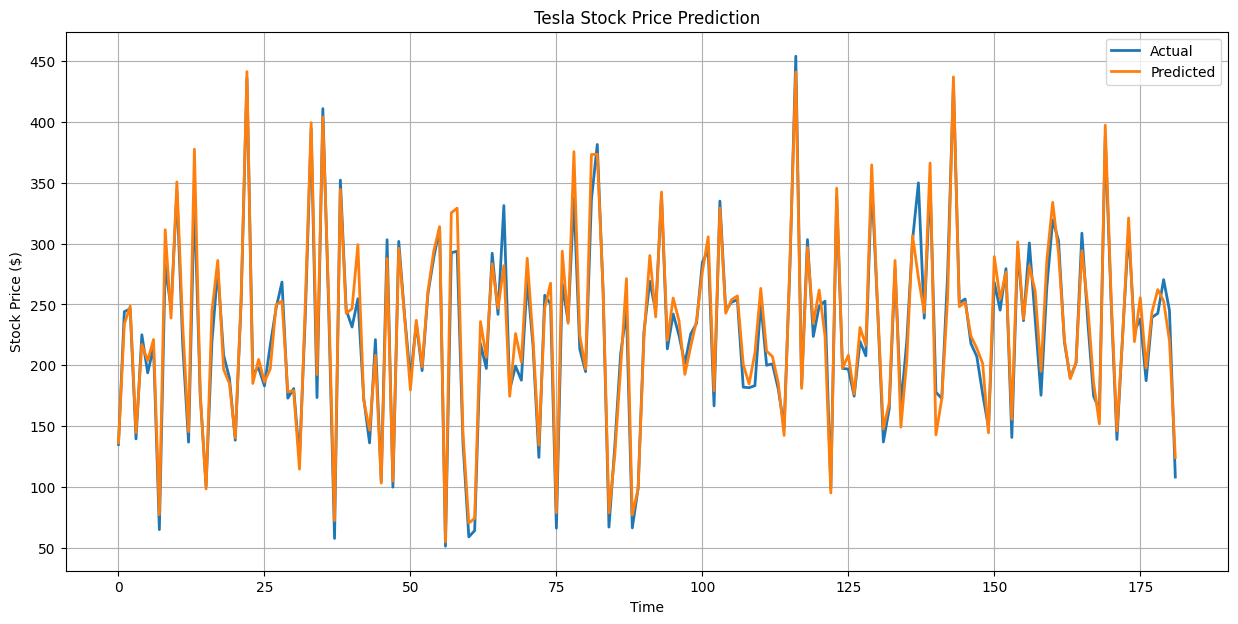

In [53]:
# Plot results
plt.figure(figsize=(15, 7))
plt.plot(y_test_inv, label='Actual', linewidth=2)
plt.plot(predictions, label='Predicted', linewidth=2)
plt.title('Tesla Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Stock Price ($)')
plt.legend()
plt.grid(True)
plt.show()

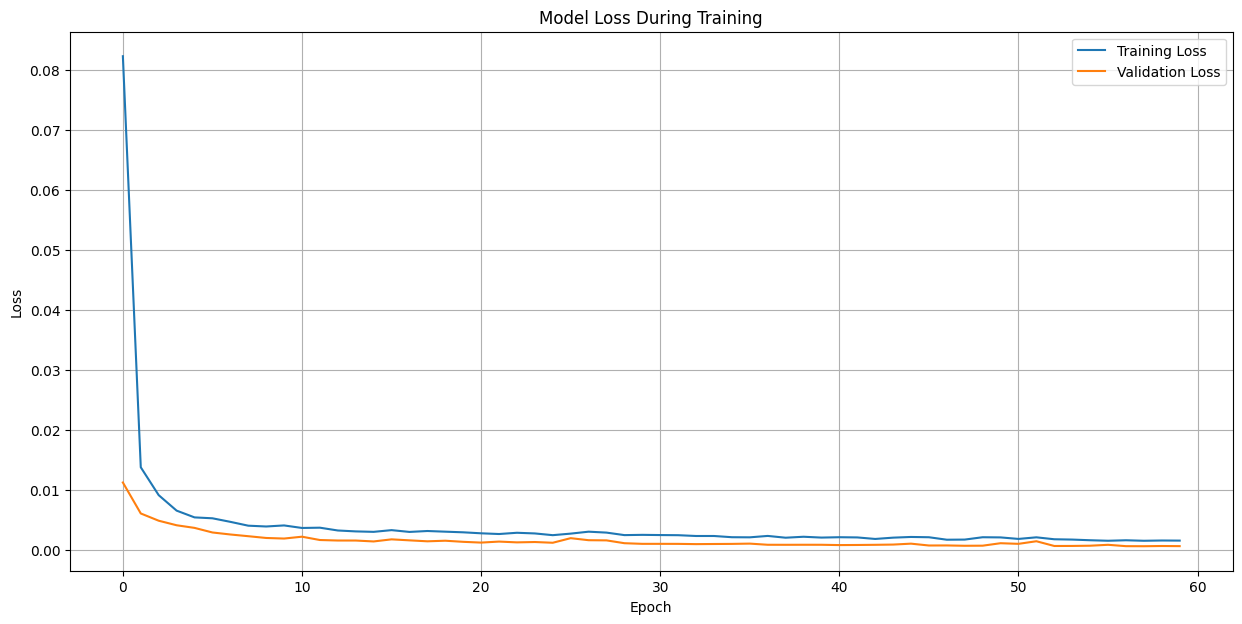

In [54]:
# Plot training history
plt.figure(figsize=(15, 7))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

##LSTM Model with hyperparameter

#Hyperparameter Optimization

Training with configuration: {'lstm_units_1': 128, 'lstm_units_2': 64, 'lstm_units_3': 32, 'dense_units': 16, 'dropout_1': 0.3, 'dropout_2': 0.3, 'dropout_3': 0.3, 'learning_rate': 0.001, 'epochs': 50, 'batch_size': 32}
Training with configuration: {'lstm_units_1': 256, 'lstm_units_2': 128, 'lstm_units_3': 64, 'dense_units': 32, 'dropout_1': 0.4, 'dropout_2': 0.4, 'dropout_3': 0.4, 'learning_rate': 0.0005, 'epochs': 50, 'batch_size': 64}
Training with configuration: {'lstm_units_1': 64, 'lstm_units_2': 32, 'lstm_units_3': 16, 'dense_units': 8, 'dropout_1': 0.2, 'dropout_2': 0.2, 'dropout_3': 0.2, 'learning_rate': 0.002, 'epochs': 50, 'batch_size': 32}

Best Configuration: {'lstm_units_1': 64, 'lstm_units_2': 32, 'lstm_units_3': 16, 'dense_units': 8, 'dropout_1': 0.2, 'dropout_2': 0.2, 'dropout_3': 0.2, 'learning_rate': 0.002, 'epochs': 50, 'batch_size': 32}
Test Loss: 0.0005852160975337029


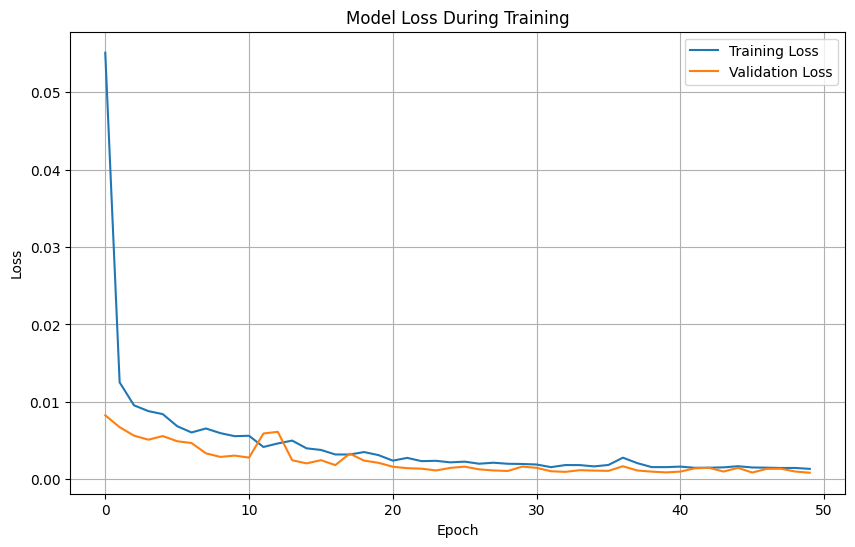

In [55]:
# Section 1: Imports and Data Preparation
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Download and prepare data
def prepare_data():
    tesla = yf.Ticker("TSLA")
    df = tesla.history(period="5y")

    # Create features
    df['Returns'] = df['Close'].pct_change()
    df['MA7'] = df['Close'].rolling(window=7).mean()
    df['MA21'] = df['Close'].rolling(window=21).mean()
    df['Volume_MA7'] = df['Volume'].rolling(window=7).mean()

    return df.dropna()

# Scale data
def scale_data(df, features, target):
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_scaled = scaler_X.fit_transform(df[features])
    y_scaled = scaler_y.fit_transform(df[[target]])

    return X_scaled, y_scaled, scaler_X, scaler_y

# Create sequences
def create_sequences(X, y, seq_length):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:(i + seq_length)])
        y_seq.append(y[i + seq_length])
    return np.array(X_seq), np.array(y_seq)

# Section 2: Model Creation
def create_model(sequence_length, n_features, config):
    model = Sequential([
        LSTM(units=config['lstm_units_1'],
             activation='tanh',
             return_sequences=True,
             input_shape=(sequence_length, n_features)),
        Dropout(config['dropout_1']),

        LSTM(units=config['lstm_units_2'],
             activation='tanh',
             return_sequences=True),
        Dropout(config['dropout_2']),

        LSTM(units=config['lstm_units_3'],
             activation='tanh'),
        Dropout(config['dropout_3']),

        Dense(config['dense_units'],
              activation='relu'),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=config['learning_rate']),
        loss='mse'
    )

    return model

# Section 3: Manual Hyperparameter Optimization
def train_evaluate_model(X_train, y_train, X_val, y_val, config, sequence_length, n_features):
    model = create_model(sequence_length, n_features, config)

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    history = model.fit(
        X_train, y_train,
        epochs=config['epochs'],
        batch_size=config['batch_size'],
        validation_data=(X_val, y_val),
        callbacks=[early_stopping],
        verbose=0
    )

    val_loss = min(history.history['val_loss'])
    return val_loss, model, history

def optimize_hyperparameters(X_train, y_train, X_val, y_val, sequence_length, n_features):
    # Define configurations to try
    configs = [
        {
            'lstm_units_1': 128,
            'lstm_units_2': 64,
            'lstm_units_3': 32,
            'dense_units': 16,
            'dropout_1': 0.3,
            'dropout_2': 0.3,
            'dropout_3': 0.3,
            'learning_rate': 0.001,
            'epochs': 50,
            'batch_size': 32
        },
        {
            'lstm_units_1': 256,
            'lstm_units_2': 128,
            'lstm_units_3': 64,
            'dense_units': 32,
            'dropout_1': 0.4,
            'dropout_2': 0.4,
            'dropout_3': 0.4,
            'learning_rate': 0.0005,
            'epochs': 50,
            'batch_size': 64
        },
        {
            'lstm_units_1': 64,
            'lstm_units_2': 32,
            'lstm_units_3': 16,
            'dense_units': 8,
            'dropout_1': 0.2,
            'dropout_2': 0.2,
            'dropout_3': 0.2,
            'learning_rate': 0.002,
            'epochs': 50,
            'batch_size': 32
        }
    ]

    best_val_loss = float('inf')
    best_config = None
    best_model = None
    best_history = None

    for config in configs:
        print(f"Training with configuration: {config}")
        val_loss, model, history = train_evaluate_model(
            X_train, y_train, X_val, y_val,
            config, sequence_length, n_features
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_config = config
            best_model = model
            best_history = history

    return best_model, best_config, best_history

# Section 4: Main Execution
def main():
    # Prepare data
    df = prepare_data()
    features = ['Close', 'Returns', 'MA7', 'MA21', 'Volume', 'Volume_MA7']
    target = 'Close'

    # Scale data
    X_scaled, y_scaled, scaler_X, scaler_y = scale_data(df, features, target)

    # Create sequences
    sequence_length = 30
    X, y = create_sequences(X_scaled, y_scaled, sequence_length)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

    # Optimize and get best model
    best_model, best_config, best_history = optimize_hyperparameters(
        X_train, y_train, X_val, y_val,
        sequence_length, len(features)
    )

    # Evaluate on test set
    test_loss = best_model.evaluate(X_test, y_test, verbose=0)
    print(f"\nBest Configuration: {best_config}")
    print(f"Test Loss: {test_loss}")

    # Plot training history
    plt.figure(figsize=(10, 6))
    plt.plot(best_history.history['loss'], label='Training Loss')
    plt.plot(best_history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss During Training')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    return best_model, scaler_X, scaler_y

if __name__ == "__main__":
    best_model, scaler_X, scaler_y = main()

## Best Configuration: {'lstm_units_1': 64, 'lstm_units_2': 32, 'lstm_units_3': 16, 'dense_units': 8, 'dropout_1': 0.2, 'dropout_2': 0.2, 'dropout_3': 0.2, 'learning_rate': 0.002, 'epochs': 50, 'batch_size': 32}
Test Loss: 0.0005852160975337029

## Category: Bagging

In [56]:
col_list = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
            'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
            'hours-per-week', 'native-country', 'income']

In [57]:
# Rename the last column
adult_df3.columns = col_list
adult_df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [58]:
# Rename the last column
adult_test3.columns = col_list
adult_test3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16281 entries, 0 to 16280
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             16281 non-null  int64 
 1   workclass       16281 non-null  object
 2   fnlwgt          16281 non-null  int64 
 3   education       16281 non-null  object
 4   education-num   16281 non-null  int64 
 5   marital-status  16281 non-null  object
 6   occupation      16281 non-null  object
 7   relationship    16281 non-null  object
 8   race            16281 non-null  object
 9   sex             16281 non-null  object
 10  capital-gain    16281 non-null  int64 
 11  capital-loss    16281 non-null  int64 
 12  hours-per-week  16281 non-null  int64 
 13  native-country  16281 non-null  object
 14  income          16281 non-null  object
dtypes: int64(6), object(9)
memory usage: 1.9+ MB


In [59]:
# Step 2: Preprocess the data

# Rename columns for easier handling (if unnamed)
adult_df3.columns = adult_df3.columns.str.strip().str.replace(' ', '_')
# Drop rows with missing values (if marked as '?')
adult_df3 = adult_df3.replace('?', pd.NA).dropna()

# Separate features and target
adult_X = adult_df3.drop(columns=['income'])
adult_y = adult_df3['income']

# Encode categorical features and target
categorical_cols_adult = adult_X.select_dtypes(include=['object']).columns
label_encoders = {}


In [60]:
# Step 2: Preprocess the data

# Rename columns for easier handling (if unnamed)
adult_test3.columns = adult_test3.columns.str.strip().str.replace(' ', '_')
# Drop rows with missing values (if marked as '?')
adult_test3 = adult_test3.replace('?', pd.NA).dropna()

# Separate features and target
adult_testX = adult_test3.drop(columns=['income'])
adult_testy = adult_test3['income']

# Encode categorical features and target
categorical_cols_adult2 = adult_testX.select_dtypes(include=['object']).columns
label_encoders2 = {}

In [61]:
adult_test3.shape

(16281, 15)

In [62]:
for col in categorical_cols_adult:
    le1 = LabelEncoder()
    adult_X[col] = le1.fit_transform(adult_X[col])
    ##label_encoders[col] = le

# Encode the target variable
adult_y = LabelEncoder().fit_transform(adult_y)

In [63]:
for col in categorical_cols_adult2:
    le2 = LabelEncoder()
    adult_testX[col] = le2.fit_transform(adult_testX[col])
    #label_encoders[col] = le

# Encode the target variable
adult_testy = LabelEncoder().fit_transform(adult_testy)

In [64]:
len(adult_y)

32561

## Individual  model -Logistic Regression, Naive Bayes and Decision Tree

In [65]:
# Logistic Regression
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(adult_X, adult_y)
logistic_pred = logistic_model.predict(adult_testX)
logistic_accuracy = accuracy_score(adult_testy, logistic_pred)
print(f'Logistic Regression Accuracy: {logistic_accuracy * 100:.2f}%')



Logistic Regression Accuracy: 80.48%


In [66]:
# Naive Bayes
naive_bayes_model = GaussianNB()
naive_bayes_model.fit(adult_X, adult_y)
naive_bayes_pred = naive_bayes_model.predict(adult_testX)
naive_bayes_accuracy = accuracy_score(adult_testy, naive_bayes_pred)
print(f'Naive Bayes Accuracy: {naive_bayes_accuracy * 100:.2f}%')


Naive Bayes Accuracy: 79.53%


In [67]:

# Decision Tree Classifier
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(adult_X, adult_y)
decision_tree_pred = decision_tree_model.predict(adult_testX)
decision_tree_accuracy = accuracy_score(adult_testy, decision_tree_pred)
print(f'Decision Tree Classifier Accuracy: {decision_tree_accuracy * 100:.2f}%')

Decision Tree Classifier Accuracy: 80.92%


# Category2: Ensemble Models:  Bagging, Boosting, Stacking
## Improved performance than individual models

In [68]:
# Encode the target variable
#y = LabelEncoder().fit_transform(y)

# Split into training and test sets
#X_train, X_test, y_train, y_test = adult_X, adult_y, adult_testX, adult_testy
# Step 3: Train Bagging Classifier
# Base learner: Decision Tree
base_learner = DecisionTreeClassifier(random_state=42)

# Bagging Classifier
bagging_clf = BaggingClassifier(
    estimator=base_learner,
    n_estimators=50,  # Number of base learners
    max_samples=0.8,  # Fraction of samples for each learner
    max_features=0.8,  # Fraction of features for each learner
    random_state=42,
    n_jobs=-1
)

# Train the Bagging Classifier
bagging_clf.fit(adult_X, adult_y)

# Step 4: Evaluate the Model
# Accuracy of Bagging
y_pred_bagging = bagging_clf.predict(adult_testX)
bagging_accuracy = accuracy_score(adult_testy, y_pred_bagging)
print(f"Bagging Classifier Accuracy: {bagging_accuracy:.4f}")

# Compare with Base Learner
base_learner.fit(adult_X, adult_y)
y_pred_base = base_learner.predict(adult_testX)
base_accuracy = accuracy_score(adult_testy, y_pred_base)
print(f"Base Learner (Decision Tree) Accuracy: {base_accuracy:.4f}")

Bagging Classifier Accuracy: 0.8566
Base Learner (Decision Tree) Accuracy: 0.8092


## Boosting

In [69]:
# Initialize the XGBoost model
model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

# Train the model
model.fit(adult_X, adult_y)

# Make predictions on the test set
y_pred = model.predict(adult_testX)

# Calculate the accuracy
accuracy = accuracy_score(adult_testy, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 87.09%


## Stacking

In [70]:
# Define the base models for stacking
base_learners = [
    ('lr', LogisticRegression(max_iter=1000)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('dt', DecisionTreeClassifier(random_state=42)),
]

# Define the meta-model
meta_model = LogisticRegression()

# Create the stacking classifier
stacking_model = StackingClassifier(estimators=base_learners, final_estimator=meta_model)

# Train the stacking model
stacking_model.fit(adult_X, adult_y)

# Make predictions on the test set
y_pred = stacking_model.predict(adult_testX)

# Calculate the accuracy
accuracy = accuracy_score(adult_testy, y_pred)
print(f'Accuracy of Stacking Model: {accuracy * 100:.2f}%')

Accuracy of Stacking Model: 85.44%
